## Question 2 breakdown: Atharva (parts A and D), Bhoomika (B and C)

In [63]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [64]:
np.random.seed(100)

num_replicates = 10
sample_sizes = [10, 100, 1000]
num_samples_per_replicate = 100

def generate_uniform_sample(size):
    return np.random.uniform(0.25, 1.25, size)

def generate_power_sample(size, alpha=3):
    return np.random.power(alpha, size)

uniform_data = {}
power_data = {}

for n in sample_sizes:
    uniform_replicates = []
    power_replicates = []
    for _ in range(num_replicates):
        uniform_replicates.append(generate_uniform_sample(num_samples_per_replicate))
        power_replicates.append(generate_power_sample(num_samples_per_replicate))
    uniform_data[n] = uniform_replicates
    power_data[n] = power_replicates

#### Part B

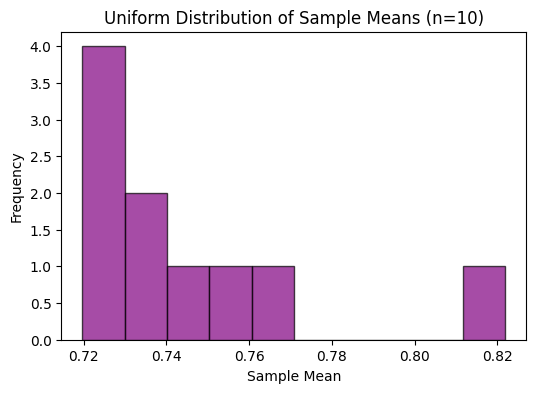

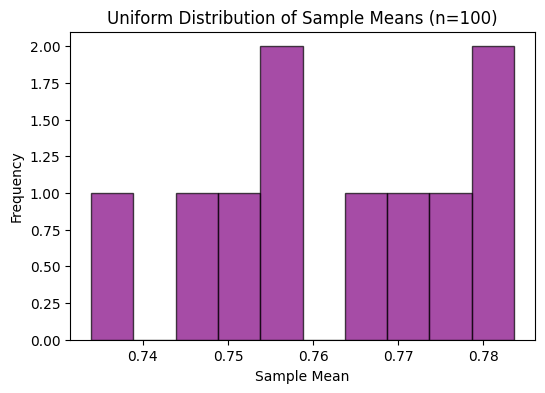

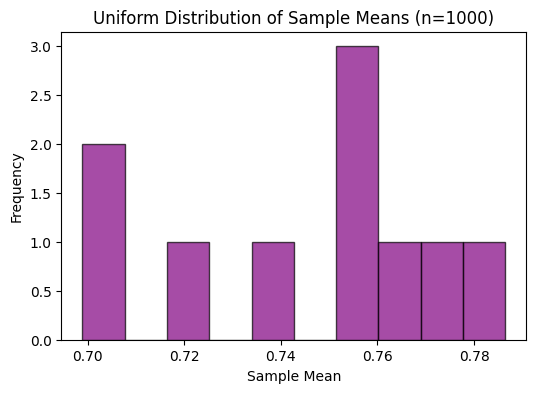

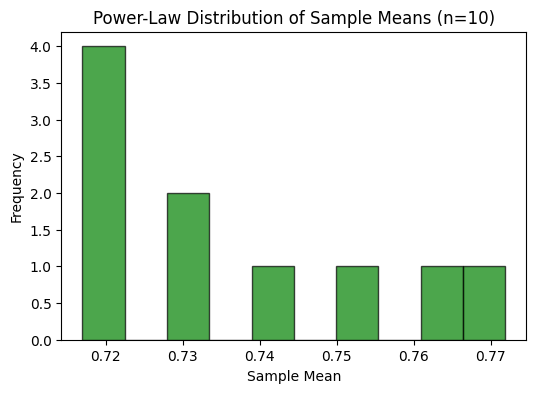

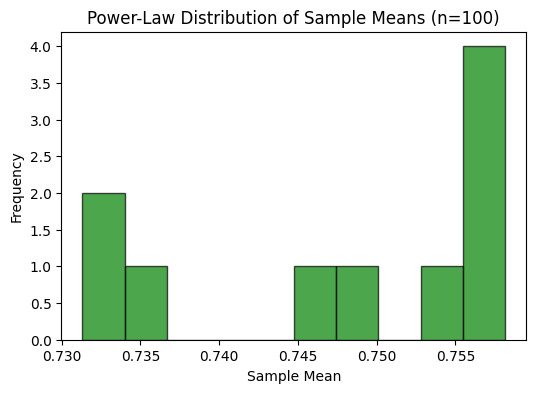

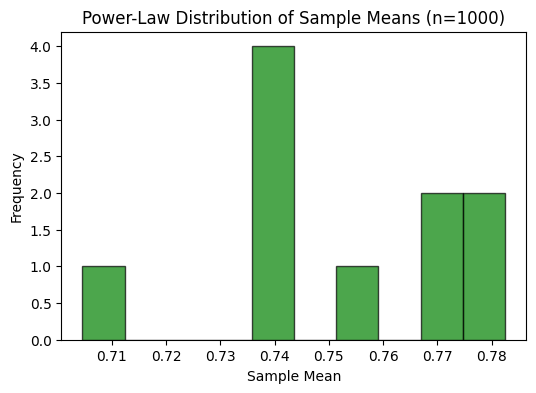

In [65]:
def compute_sample_means(data_dict):
    sample_means = {}
    for n, replicates in data_dict.items():
        means = [np.mean(rep) for rep in replicates]
        sample_means[n] = means
    return sample_means

uniform_means = compute_sample_means(uniform_data)
power_means = compute_sample_means(power_data)


def plot_sample_mean_distributions(sample_means, dist_name, color):
    for n, means in sample_means.items():
        plt.figure(figsize=(6, 4))
        plt.hist(means, bins=10, color=color, edgecolor='black', alpha=0.7)
        plt.title(f"{dist_name} Distribution of Sample Means (n={n})")
        plt.xlabel("Sample Mean")
        plt.ylabel("Frequency")
        plt.show()

# Plot Uniform distribution sample means
plot_sample_mean_distributions(uniform_means, "Uniform", "purple")

# Plot Power-Law distribution sample means
plot_sample_mean_distributions(power_means, "Power-Law", "green")

#### Part C

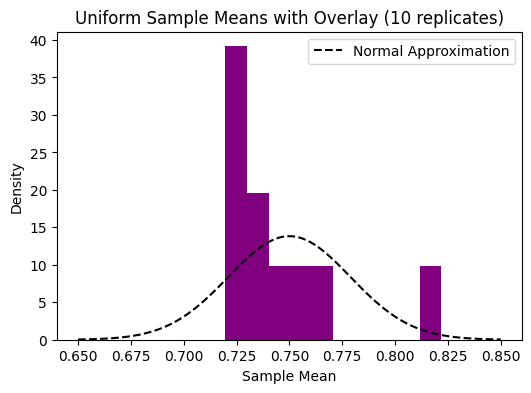

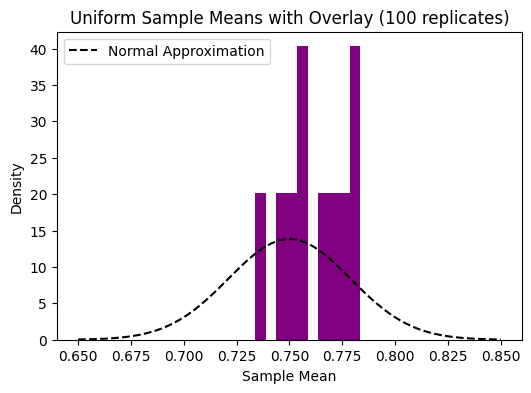

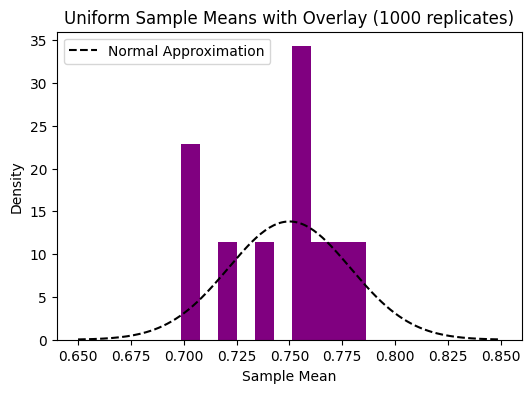

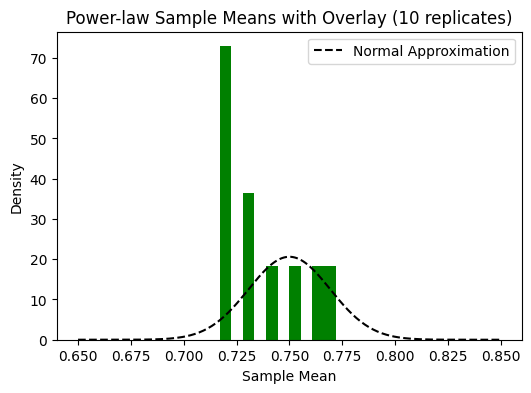

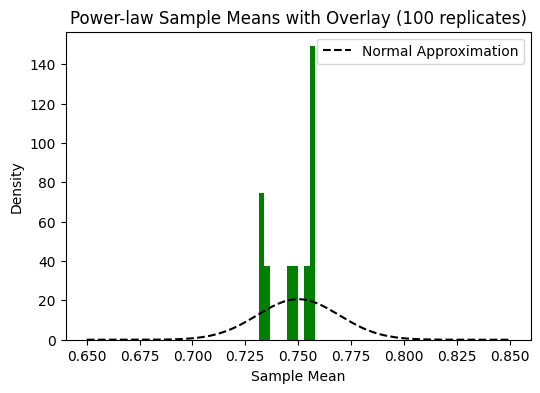

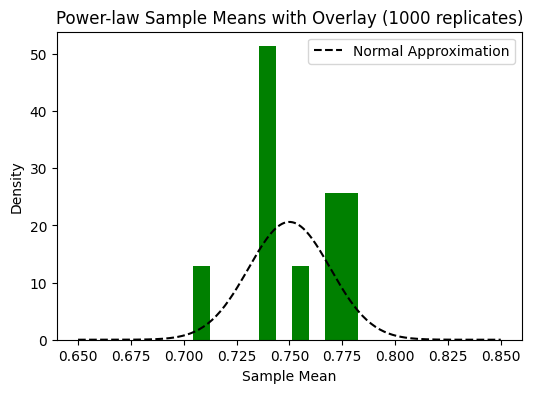

In [66]:

for n in sample_sizes:
    plt.figure(figsize=(6,4))
    plt.hist(uniform_means[n], bins=10, density=True, color='purple')
    x = np.linspace(.65, .85, 200)
    plt.plot(x, norm.pdf(x, 0.75, 0.2887/np.sqrt(num_samples_per_replicate)),
             'k--', label='Normal Approximation')
    plt.title(f'Uniform Sample Means with Overlay ({n} replicates)')
    plt.xlabel('Sample Mean')
    plt.ylabel('Density')
    plt.legend()
    plt.show()

for n in sample_sizes:
    plt.figure(figsize=(6,4))
    plt.hist(power_means[n], bins=10, density=True, color='green')
    x = np.linspace(.65, .85, 200)
    plt.plot(x, norm.pdf(x, 0.75, 0.1936/np.sqrt(num_samples_per_replicate)),
             'k--', label='Normal Approximation')
    plt.title(f'Power-law Sample Means with Overlay ({n} replicates)')
    plt.xlabel('Sample Mean')
    plt.ylabel('Density')
    plt.legend()
    plt.show()
